<a href="https://colab.research.google.com/github/adimika04-collab/Analisis-Regresi/blob/main/UAS_Anreg_Mika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import os

from scipy.stats import pearsonr
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.api import linear_reset

# Data

In [28]:
drive.mount('/content/gdrive')
data = pd.read_csv('/content/gdrive/My Drive/Analisis Regresi/karhutla_307.csv')

print("Data awal:")
print(data.head())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(data.describe())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Data awal:
   waktu  jumlah_hotspot  curah_hujan       suhu  kelembaban  kecepatan_angin  \
0      0      233.609330   183.654594  32.182294   68.107713         3.382113   
1      1      241.815585   260.059637  31.202679   68.764219         5.553213   
2      2      258.610989   229.110014  31.448469   70.338933         5.731792   
3      3      294.328682   181.050964  29.478840   72.476545         4.693666   
4      4     1044.536069   118.312539  31.809061   67.964348         3.914112   

   luas_gambut  aktivitas_manusia  
0  5727.677896           2.044973  
1  5218.746494           0.550249  
2  3056.574707          -0.468249  
3  2374.135854           0.256848  
4  5359.656808          -0.765118  

Statistik Deskriptif:
            waktu  jumlah_hotspot  curah_hujan        suhu  kelembaban  \
count  200.000000      200.000000   200.000000  200.000000

# Missing Value

In [42]:
kolom = ['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']

print("\nCek Missing Value:")
print(data[kolom].isnull().sum())




Cek Missing Value:
jumlah_hotspot       0
curah_hujan          0
suhu                 0
kelembaban           0
kecepatan_angin      0
luas_gambut          0
aktivitas_manusia    0
dtype: int64


# Outlier

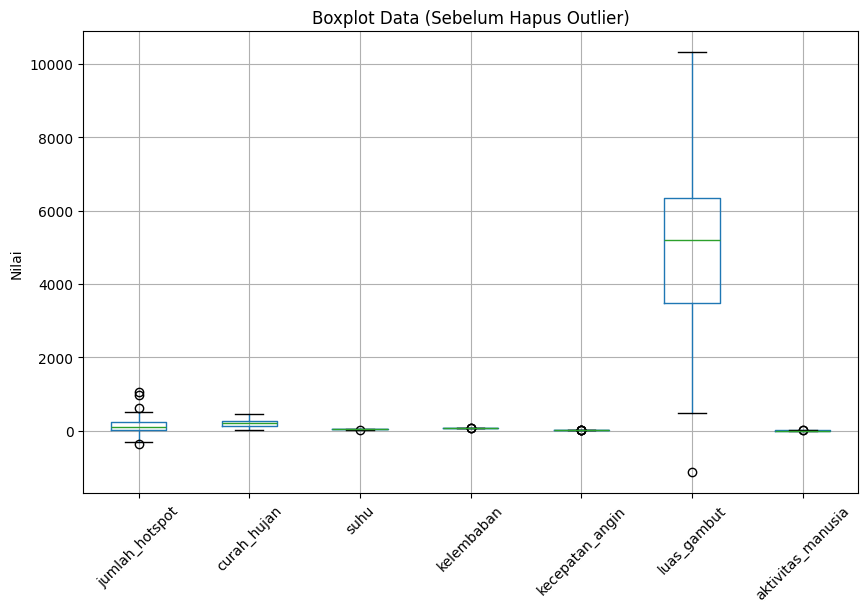


Jumlah outlier tiap variabel:
jumlah_hotspot       4
curah_hujan          0
suhu                 1
kelembaban           3
kecepatan_angin      5
luas_gambut          1
aktivitas_manusia    2
dtype: int64


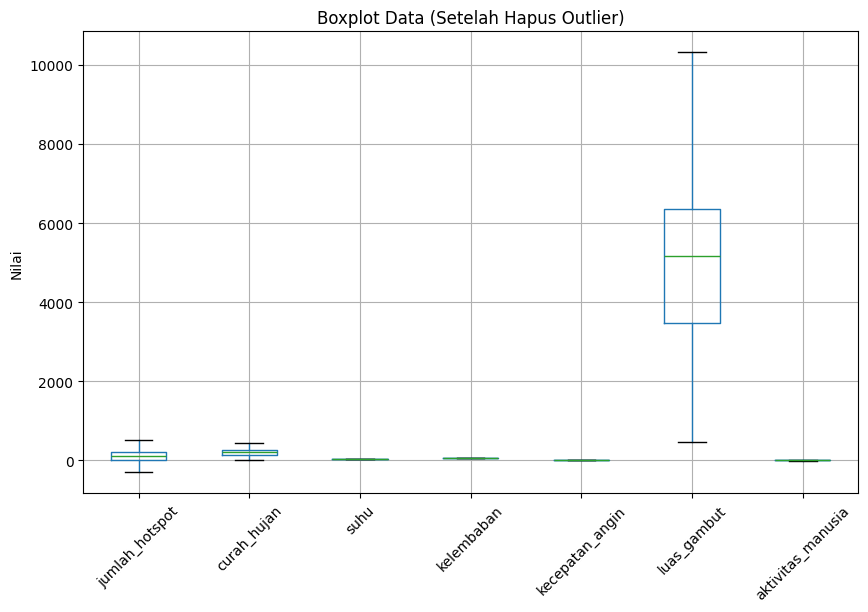


Jumlah outlier tiap variabel (SETELAH dibersihkan):
jumlah_hotspot       0
curah_hujan          0
suhu                 0
kelembaban           0
kecepatan_angin      0
luas_gambut          0
aktivitas_manusia    0
dtype: int64


In [30]:
Q1 = data[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']].quantile(0.25)
Q3 = data[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']].quantile(0.75)
IQR = Q3 - Q1

outlier = ((data[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']] < (Q1 - 1.5 * IQR)) |
           (data[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']] > (Q3 + 1.5 * IQR)))

plt.figure(figsize=(10,6))
data[kolom].boxplot()
plt.title("Boxplot Data (Sebelum Hapus Outlier)")
plt.ylabel("Nilai")
plt.xticks(rotation=45)
plt.show()

print("\nJumlah outlier tiap variabel:")
print(outlier.sum())

# Hapus data yang mengandung outlier
data_clean = data[~outlier.any(axis=1)]

plt.figure(figsize=(10,6))
data_clean[kolom].boxplot()
plt.title("Boxplot Data (Setelah Hapus Outlier)")
plt.ylabel("Nilai")
plt.xticks(rotation=45)
plt.show()

Q1_clean = data_clean[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']].quantile(0.25)
Q3_clean = data_clean[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']].quantile(0.75)
IQR_clean = Q3_clean - Q1_clean

outlier_clean = ((data_clean[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']] < (Q1_clean - 1.5 * IQR_clean)) |
                 (data_clean[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']] > (Q3_clean + 1.5 * IQR_clean)))

print("\nJumlah outlier tiap variabel (SETELAH dibersihkan):")
print(outlier_clean.sum())



# Korelasi Pearson


Korelasi Pearson


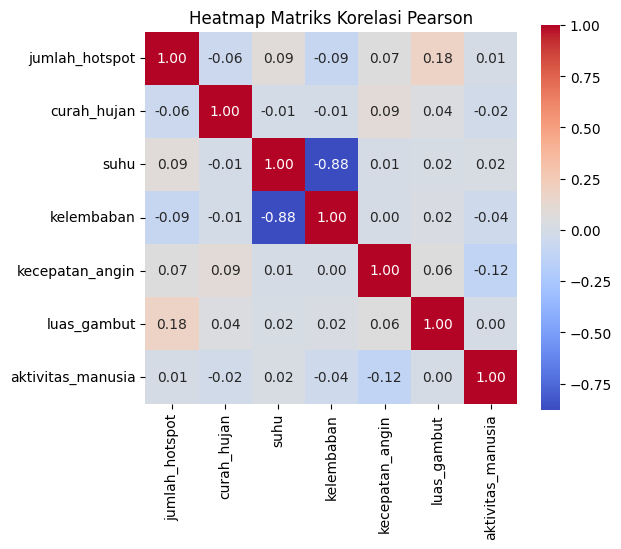


Korelasi dengan jumlah_hotspot:
curah_hujan: r = -0.064, p-value = 0.3856
Interpretasi: Hubungan negatif dengan kekuatan lemah.
suhu: r = 0.088, p-value = 0.2329
Interpretasi: Hubungan positif dengan kekuatan lemah.
kelembaban: r = -0.094, p-value = 0.2048
Interpretasi: Hubungan negatif dengan kekuatan lemah.
kecepatan_angin: r = 0.066, p-value = 0.3715
Interpretasi: Hubungan positif dengan kekuatan lemah.
luas_gambut: r = 0.183, p-value = 0.0125
Interpretasi: Hubungan positif dengan kekuatan lemah.
aktivitas_manusia: r = 0.007, p-value = 0.9223
Interpretasi: Hubungan positif dengan kekuatan lemah.


In [31]:
print("\nKorelasi Pearson")
corr_matrix = data_clean[['jumlah_hotspot', 'curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap Matriks Korelasi Pearson")
plt.show()

print("\nKorelasi dengan jumlah_hotspot:")
for var in ['curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']:
    r, p = pearsonr(data_clean['jumlah_hotspot'], data_clean[var])
    arah = "positif" if r > 0 else "negatif"
    kekuatan = "lemah" if abs(r) < 0.3 else "sedang" if abs(r) < 0.6 else "kuat"
    print(f"{var}: r = {r:.3f}, p-value = {p:.4f}")
    print(f"Interpretasi: Hubungan {arah} dengan kekuatan {kekuatan}.")

# Model Regresi

In [32]:
# Variabel
Y = data_clean['jumlah_hotspot']
X = data_clean[['curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print("\nHasil Regresi:")
print(model.summary())

# Menampilkan Model
b0 = model.params['const']
b1 = model.params['curah_hujan']
b2 = model.params['suhu']
b3 = model.params['kelembaban']
b4 = model.params['kecepatan_angin']
b5 = model.params['luas_gambut']
b6 = model.params['aktivitas_manusia']

print("\nPersamaan Model Regresi")
print(f"Y = {b0:.3f} + ({b1:.3f})*X1 + ({b2:.3f})*X2 + ({b3:.3f})*X3 + ({b4:.3f})*X4 + ({b5:.3f})*X5 + ({b6:.3f})*X6")

r2 = model.rsquared
adj_r2 = model.rsquared_adj

print(f"\nR-square = {r2:.3f}")
print(f"Adjusted R-square = {adj_r2:.3f}")

print("\nInterpretasi R-square:")
print(f"Nilai R-square sebesar {r2:.3f} menunjukkan bahwa "
      f"{r2*100:.2f}% variasi jumlah hotspot "
      f"dapat dijelaskan oleh variabel curah hujan, suhu, kelembaban, "
      f"kecepatan angin, luas gambut, dan aktivitas manusia secara bersama-sama, "
      f"sedangkan sisanya sebesar {(1-r2)*100:.2f}% dijelaskan oleh "
      f"faktor lain di luar model.")

# Prediksi
y_pred = model.predict(X)

# RMSE
rmse = np.sqrt(mean_squared_error(Y, y_pred))
print("RMSE :", rmse)


Hasil Regresi:
                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.644
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.137
Time:                        06:09:16   Log-Likelihood:                -1206.9
No. Observations:                 185   AIC:                             2428.
Df Residuals:                     178   BIC:                             2450.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               66

# Uji Linearitas


=== Scatter Plot Data Asli ===


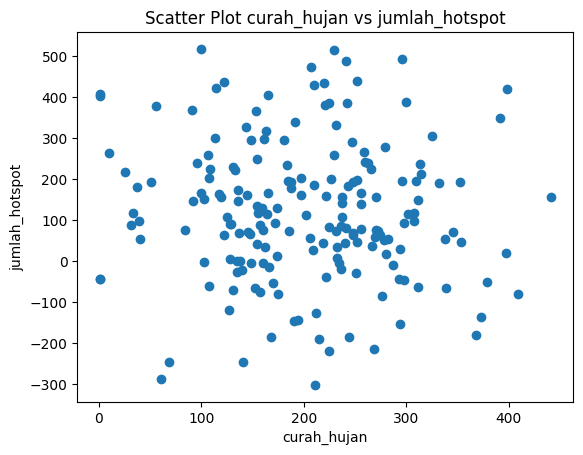

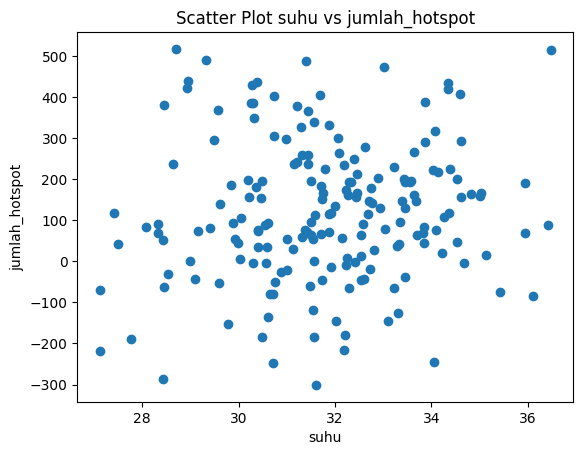

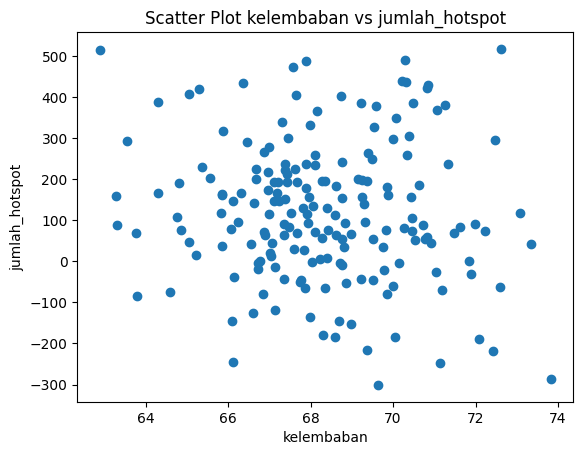

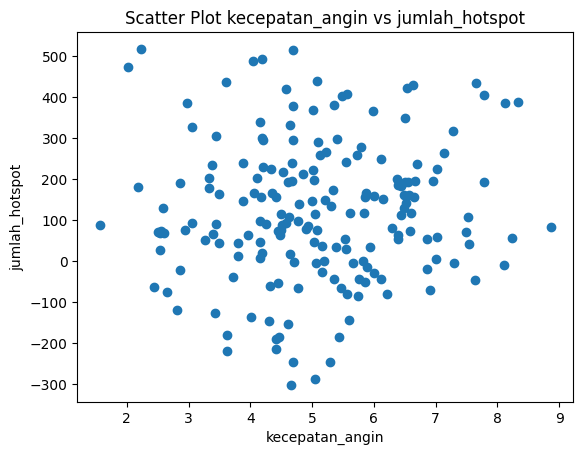

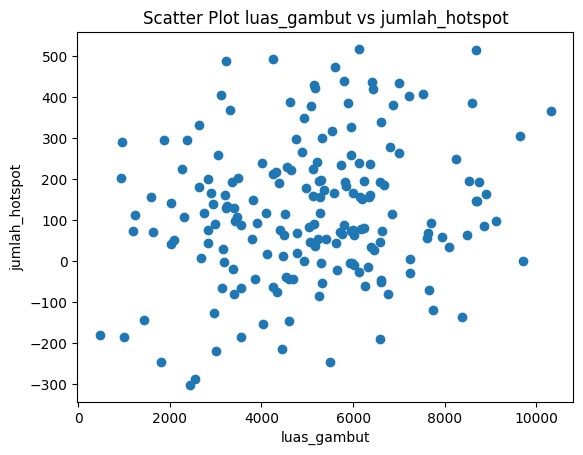

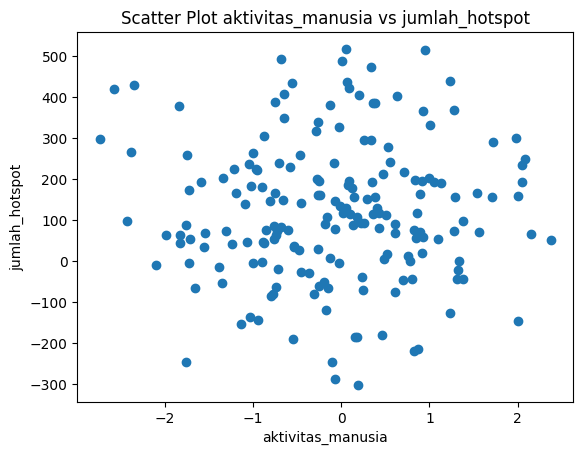

=== UJI RAMSEY RESET ===
p-value: 0.8204361591905978

KESIMPULAN:
Model sudah memenuhi asumsi linearitas
Nilai RMSE: 164.8507

=== Scatter Plot Residual ===


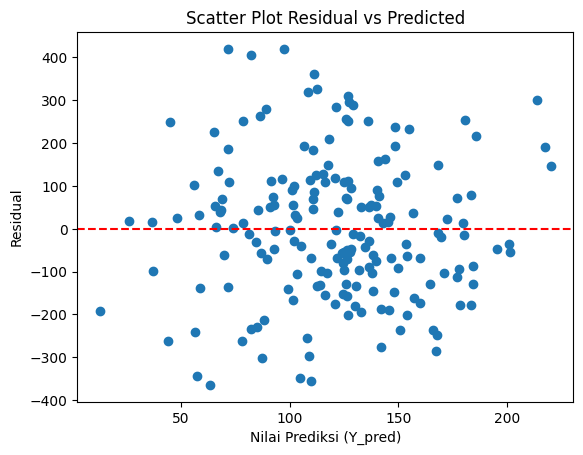

In [33]:
# Scatter Plot for each independent variable against Y
print('\n=== Scatter Plot Data Asli ===')
for col in X.columns:
    if col != 'const':
        plt.scatter(X[col], Y)
        plt.title(f'Scatter Plot {col} vs jumlah_hotspot')
        plt.xlabel(col)
        plt.ylabel('jumlah_hotspot')
        plt.show()

reset_test = linear_reset(
    model,
    power=2,
    use_f=True
)

p_value = reset_test.pvalue
print("=== UJI RAMSEY RESET ===")
print("p-value:", p_value)
if p_value > 0.05:
    print("\nKESIMPULAN:")
    print("Model sudah memenuhi asumsi linearitas")
else:
    print("\nKESIMPULAN:")
    print("Model tidak linear")
    print("Perlu dilakukan transformasi")

Y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(Y, Y_pred))
print("Nilai RMSE:", round(rmse, 4))

# Scatter Plot Residual
residual = Y - Y_pred
print('\n=== Scatter Plot Residual ===')
plt.scatter(Y_pred, residual)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Scatter Plot Residual vs Predicted')
plt.xlabel('Nilai Prediksi (Y_pred)')
plt.ylabel('Residual')
plt.show()

# Uji Signifikansi

In [34]:
alpha = 0.05
# Uji t
print("\n=== Uji t ===")
for var, pval in model.pvalues.items():
    if var == 'const':
        continue

    if pval < alpha:
        print(f"{var}: Berpengaruh signifikan terhadap Y (Tolak H0)")
    else:
        print(f"{var}: Tidak signifikan (Gagal tolak H0)")

# Uji F
print("\n=== Uji F ===")
if model.f_pvalue < alpha:
    print("Tolak H0: Variabel independen berpengaruh secara simultan")
else:
    print("Gagal tolak H0: Tidak ada pengaruh simultan")


=== Uji t ===
curah_hujan: Tidak signifikan (Gagal tolak H0)
suhu: Tidak signifikan (Gagal tolak H0)
kelembaban: Tidak signifikan (Gagal tolak H0)
kecepatan_angin: Tidak signifikan (Gagal tolak H0)
luas_gambut: Berpengaruh signifikan terhadap Y (Tolak H0)
aktivitas_manusia: Tidak signifikan (Gagal tolak H0)

=== Uji F ===
Gagal tolak H0: Tidak ada pengaruh simultan


# Uji Asumsi Klasik

In [35]:
residual = model.resid

# Normalitas
stat, p = shapiro(residual)
print("\nUji Normalitas (Shapiro-Wilk):")
print("Statistik =", stat, "p-value =", p)
if p > 0.05:
    print(f"Karena nilai p-value {p} > 0.05, maka residual berdistribusi normal (asumsi normalitas terpenuhi).")
else:
    print(f"Karena nilai p-value {p} < 0.05, maka residual tidak berdistribusi normal (asumsi normalitas tidak terpenuhi).")

# Multikolinearitas (VIF)
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nUji Multikolinearitas (VIF):")
print(vif_data)
if (vif_data["VIF"] < 5).all():
    print("Interpretasi: Tidak terdapat multikolinearitas antar variabel bebas.")
else:
    print("Interpretasi: Terdapat multikolinearitas pada beberapa variabel bebas.")

# Heteroskedastisitas
bp_test = het_breuschpagan(residual, X)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_result = dict(zip(labels, bp_test))

print("\nUji Heteroskedastisitas (Breusch-Pagan):")
print(bp_result)

if bp_result['LM-Test p-value'] > 0.05:
    print("Interpretasi: Tidak terjadi heteroskedastisitas (model bersifat homoskedastis).")
else:
    print("Interpretasi: Terjadi heteroskedastisitas (asumsi homoskedastisitas tidak terpenuhi).")

# Autokorelasi
dw = durbin_watson(residual)
print("\nUji Autokorelasi (Durbin-Watson):")
print("Nilai DW =", dw)
if 1.5 < dw < 2.5:
    print("Interpretasi: Tidak terdapat autokorelasi pada residual.")
elif dw <= 1.5:
    print("Interpretasi: Terdapat autokorelasi positif.")
else:
    print("Interpretasi: Terdapat autokorelasi negatif.")


Uji Normalitas (Shapiro-Wilk):
Statistik = 0.9911409368569495 p-value = 0.31423373779693375
Karena nilai p-value 0.31423373779693375 > 0.05, maka residual berdistribusi normal (asumsi normalitas terpenuhi).

Uji Multikolinearitas (VIF):
            Variabel          VIF
0              const  9740.548408
1        curah_hujan     1.012722
2               suhu     4.444764
3         kelembaban     4.451340
4    kecepatan_angin     1.027251
5        luas_gambut     1.012161
6  aktivitas_manusia     1.017055
Interpretasi: Terdapat multikolinearitas pada beberapa variabel bebas.

Uji Heteroskedastisitas (Breusch-Pagan):
{'LM Statistic': np.float64(9.242036034650082), 'LM-Test p-value': np.float64(0.16041670933342692), 'F-Statistic': np.float64(1.559988498816129), 'F-Test p-value': np.float64(0.16137638665598897)}
Interpretasi: Tidak terjadi heteroskedastisitas (model bersifat homoskedastis).

Uji Autokorelasi (Durbin-Watson):
Nilai DW = 0.7847968362295564
Interpretasi: Terdapat autokorelasi

# Atasi Autokorelasi

In [36]:
import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.stattools import durbin_watson

# 1. Gunakan semua variabel asli (tanpa drop suhu & kelembaban)
features = ['curah_hujan', 'suhu', 'kelembaban', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']
X = data_clean[features]
X = sm.add_constant(X)
Y = data_clean['jumlah_hotspot']

# 2. Hitung residual model awal untuk estimasi rho
model_awal = sm.OLS(Y, X).fit()
resid = model_awal.resid
rho = resid.autocorr(lag=1)

print(f"Estimasi rho (autokorelasi): {rho:.4f}")

# 3. Transformasi Cochrane-Orcutt untuk SEMUA variabel
# Transformasi Y
Y_CO = data_clean['jumlah_hotspot'].iloc[1:].reset_index(drop=True) - rho * data_clean['jumlah_hotspot'].iloc[:-1].reset_index(drop=True)

# Transformasi X (Looping otomatis untuk semua variabel)
X_CO_dict = {}
for col in features:
    X_CO_dict[f'{col}_CO'] = data_clean[col].iloc[1:].reset_index(drop=True) - rho * data_clean[col].iloc[:-1].reset_index(drop=True)

# 4. Buat DataFrame baru hasil transformasi
df_CO = pd.DataFrame(X_CO_dict)
df_CO['Y_CO'] = Y_CO
df_CO = df_CO.dropna()

# 5. Bangun Model Final dengan data yang sudah ditransformasi
X_final = df_CO[[f'{col}_CO' for col in features]]
X_final = sm.add_constant(X_final) # Konstanta di sini mewakili intercept(1 - rho)

model_CO = sm.OLS(df_CO['Y_CO'], X_final).fit()

print("\n=== MODEL COCHRANE–ORCUTT (SEMUA VARIABEL) ===")
print(model_CO.summary())

# 6. Cek Durbin-Watson Baru
dw_CO = durbin_watson(model_CO.resid)
print(f"\nNilai Durbin-Watson Setelah Perbaikan: {dw_CO:.4f}")

if 1.5 <= dw_CO <= 2.5:
    print("Interpretasi: Masalah autokorelasi berhasil diatasi.")
else:
    print("Interpretasi: Periksa kembali, autokorelasi mungkin masih ada.")

Estimasi rho (autokorelasi): 0.6062

=== MODEL COCHRANE–ORCUTT (SEMUA VARIABEL) ===
                            OLS Regression Results                            
Dep. Variable:                   Y_CO   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.624
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.143
Time:                        06:09:19   Log-Likelihood:                -1153.8
No. Observations:                 184   AIC:                             2322.
Df Residuals:                     177   BIC:                             2344.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

# Kandidat Model

In [37]:
import itertools

def evaluasi_model(X_input, y_input):
    X_const = sm.add_constant(X_input, has_constant='add')
    model = sm.OLS(y_input, X_const).fit()
    y_pred = model.predict(X_const)
    rmse = np.sqrt(mean_squared_error(y_input, y_pred))
    return model, model.rsquared, model.rsquared_adj, rmse

# 1. Pastikan Dependent Variable sesuai
y = df_CO['Y_CO']

# 2. Update list variabel: Masukkan kembali suhu dan kelembaban
# Kita gunakan semua variabel yang sudah di-transformasi tadi
variables_CO = [
    'curah_hujan_CO',
    'suhu_CO',
    'kelembaban_CO',
    'kecepatan_angin_CO',
    'luas_gambut_CO',
    'aktivitas_manusia_CO'
]

# Bentuk kandidat model (Proses iterasi tetap sama)
models = {}
for k in range(1, len(variables_CO) + 1):
    for combo in itertools.combinations(variables_CO, k):
        model_name = combo
        models[model_name] = df_CO[list(combo)]

hasil = []
model_objs = {}

for nama, X in models.items():
    returned_model, r2, adj_r2, rmse = evaluasi_model(X, y)
    hasil.append([nama, r2, adj_r2, rmse])
    model_objs[nama] = returned_model

# 3. Tampilkan Tabel Perbandingan
hasil_data = pd.DataFrame(hasil, columns=['Model','R2','Adjusted R2','RMSE'])
hasil_data = hasil_data.sort_values(by='Adjusted R2', ascending=False)

print("===== TABEL PERBANDINGAN MODEL SETELAH COCHRANE-ORCUTT ====")
# Menampilkan 10 teratas saja agar tidak terlalu panjang di output
display(hasil_data.head(10))

best_model_name = hasil_data.iloc[0]['Model']

print("\n===== INTERPRETASI TABEL ====")
print(f"Model terbaik adalah: {best_model_name}")
print(f"Adjusted R2 tertinggi: {hasil_data.iloc[0]['Adjusted R2']:.4f}")
print("Dipilih karena mempertimbangkan keseimbangan antara performa (R2) dan jumlah variabel.")

===== TABEL PERBANDINGAN MODEL SETELAH COCHRANE-ORCUTT ====


,Model,R2,Adjusted R2,RMSE
23,"(curah_hujan_CO, suhu_CO, luas_gambut_CO)",0.047143,0.031262,128.278960
46,"(curah_hujan_CO, suhu_CO, luas_gambut_CO, akti...",0.051213,0.030011,128.004689
42,"(curah_hujan_CO, suhu_CO, kelembaban_CO, luas_...",0.047824,0.026547,128.233092
44,"(curah_hujan_CO, suhu_CO, kecepatan_angin_CO, ...",0.047191,0.025899,128.275759
13,"(suhu_CO, luas_gambut_CO)",0.036440,0.025793,128.997391
58,"(curah_hujan_CO, suhu_CO, kelembaban_CO, luas_...",0.052155,0.025530,127.941130
36,"(suhu_CO, luas_gambut_CO, aktivitas_manusia_CO)",0.040980,0.024996,128.693177
59,"(curah_hujan_CO, suhu_CO, kecepatan_angin_CO, ...",0.051236,0.024586,128.003137
26,"(curah_hujan_CO, kelembaban_CO, luas_gambut_CO)",0.038981,0.022964,128.827176
6,"(curah_hujan_CO, suhu_CO)",0.033269,0.022587,129.209479



===== INTERPRETASI TABEL ====
Model terbaik adalah: ('curah_hujan_CO', 'suhu_CO', 'luas_gambut_CO')
Adjusted R2 tertinggi: 0.0313
Dipilih karena mempertimbangkan keseimbangan antara performa (R2) dan jumlah variabel.


# Prediksi dengan Model Terbaik

Variabel model terbaik:
['curah_hujan_CO', 'suhu_CO', 'luas_gambut_CO']

===== HASIL EVALUASI MODEL =====
RMSE : 115.8955
MAE  : 85.7428
MAPE : 312.14%

===== SUMMARY MODEL TERBAIK =====
                            OLS Regression Results                            
Dep. Variable:                   Y_CO   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     3.255
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0235
Time:                        06:09:20   Log-Likelihood:                -925.94
No. Observations:                 147   AIC:                             1860.
Df Residuals:                     143   BIC:                             1872.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     co

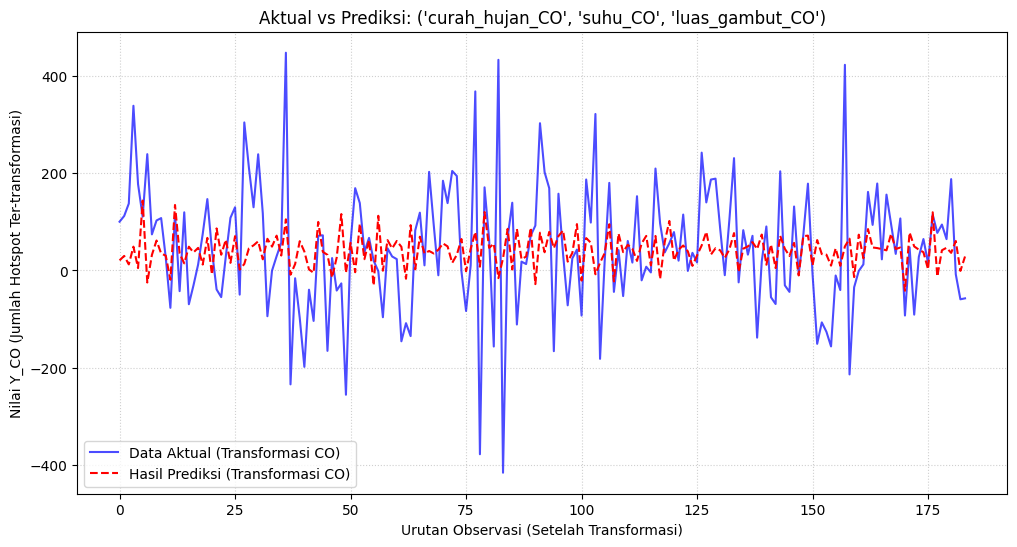

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Mengambil Model Terbaik
best_variables = list(best_model_name)
print("Variabel model terbaik:")
print(best_variables)

# Membentuk Variabel
X_best = df_CO[best_variables]
y_best = df_CO['Y_CO']

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y_best,
    test_size=0.2,
    random_state=42
)

# Tambahkan konstanta
X_train = sm.add_constant(X_train, has_constant='add')
X_test = sm.add_constant(X_test, has_constant='add')

# Bangun Model Terbaik
final_model = sm.OLS(y_train, X_train).fit()

# Prediksi
y_pred = final_model.predict(X_test)

# Evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\n===== HASIL EVALUASI MODEL =====")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\n===== SUMMARY MODEL TERBAIK =====")
print(final_model.summary())

# Plot Aktual vs Prediksi
X_all = sm.add_constant(X_best, has_constant='add')
y_all_pred = final_model.predict(X_all)

plt.figure(figsize=(12,6))
# Gunakan .reset_index(drop=True) agar sumbu X mulai dari 0 sampai selesai secara berurutan
plt.plot(y_best.reset_index(drop=True),
         label='Data Aktual (Transformasi CO)',
         color='blue', alpha=0.7)
plt.plot(pd.Series(y_all_pred).reset_index(drop=True),
         label='Hasil Prediksi (Transformasi CO)',
         color='red', linestyle='--')

plt.title(f'Aktual vs Prediksi: {best_model_name}')
plt.xlabel('Urutan Observasi (Setelah Transformasi)')
plt.ylabel('Nilai Y_CO (Jumlah Hotspot Ter-transformasi)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
